## Modelo de regresion con ingenieria de variables

En esta seccion se implementa un flujo completo para predecir Consumption:
- Carga y exploracion del CSV original.
- Analisis de variables candidatas desde el dataset fuente.
- Ingenieria temporal + one-hot encoding para hour, day_of_week, month, quarter y year.
- Split tradicional aleatorio train/validation/test (no temporal).
- Entrenamiento y evaluacion con Gradient Boosting Regressor.
- No se escalan las features porque los modelos basados en arboles toman decisiones mediante umbrales.
- Visualizacion de predicciones, residuales e importancia de variables.

In [1]:
# Librerias base para manipulacion de datos y visualizacion
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Gradient Boosting y metricas de evaluacion
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Herramienta de split tradicional
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Ajustes de visualizacion para tablas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [2]:
# Construimos una ruta relativa robusta al archivo fuente
csv_path = Path('..') / '03 regression' / 'code' / 'electricityConsumptionAndProductioction.csv'
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontro el archivo: {csv_path.resolve()}')

# Cargamos datos originales (consumo + produccion por fuente)
raw = pd.read_csv(csv_path)

# Convertimos DateTime a formato fecha y lo usamos como indice temporal
raw['DateTime'] = pd.to_datetime(raw['DateTime'])
raw = raw.sort_values('DateTime').set_index('DateTime')

# Resumen rapido para entender tamano, columnas y posibles faltantes
print('Shape del dataset original:', raw.shape)
print('Columnas disponibles:', list(raw.columns))
print('Valores nulos por columna:')
print(raw.isna().sum())

# Visualizamos primeras filas del dataset completo
display(raw.head())

Shape del dataset original: (62810, 9)
Columnas disponibles: ['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
Valores nulos por columna:
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [3]:
# Analisis de variables candidatas para explicar Consumption
# Evaluamos correlacion lineal de cada variable original contra el target.

candidate_cols = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'Consumption'
]

corr_with_target = raw[candidate_cols].corr(numeric_only=True)['Consumption'] \
    .drop('Consumption') \
    .sort_values(key=np.abs, ascending=False)

print('Correlacion (ordenada por magnitud absoluta) con Consumption:')
display(corr_with_target.to_frame('corr_vs_consumption'))

# Breve conclusion automatica de candidatas
strong_candidates = corr_with_target[np.abs(corr_with_target) >= 0.25].index.tolist()
moderate_candidates = corr_with_target[(np.abs(corr_with_target) >= 0.10) & (np.abs(corr_with_target) < 0.25)].index.tolist()

print('Candidatas fuertes (|corr| >= 0.25):', strong_candidates)
print('Candidatas moderadas (0.10 <= |corr| < 0.25):', moderate_candidates)

Correlacion (ordenada por magnitud absoluta) con Consumption:


,corr_vs_consumption
Production,0.690823
Oil and Gas,0.499442
Coal,0.472298
Biomass,0.400475
Hydroelectric,0.358047
Nuclear,0.161838
Wind,0.102026
Solar,-0.048037


Candidatas fuertes (|corr| >= 0.25): ['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric']
Candidatas moderadas (0.10 <= |corr| < 0.25): ['Nuclear', 'Wind']


In [4]:
# Funcion para generar variables temporales a partir del indice de fechas
def create_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['hour'] = out.index.hour
    out['day_of_week'] = out.index.day_of_week
    out['month'] = out.index.month
    out['quarter'] = out.index.quarter
    out['year'] = out.index.year
    out['day_of_year'] = out.index.dayofyear
    return out

# Parte 1: ingenieria de variables (aislada, sin split)
feat_df = create_time_features(raw)

# Variables candidatas del dataset de origen (produccion total y por tecnologia)
energy_candidate_features = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass'
]

# Variables categoricas temporales a codificar con one-hot
categorical_time_features = ['hour', 'day_of_week', 'month', 'quarter', 'year']

# One-hot encoding para convertir categorias temporales en variables dummy
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
encoded_array = encoder.fit_transform(feat_df[categorical_time_features])
encoded_cols = encoder.get_feature_names_out(categorical_time_features)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=feat_df.index)

# Variables numericas adicionales (incluye dia del anio como tendencia estacional)
numeric_features = energy_candidate_features + ['day_of_year']

# Dataframe final de modelado con target + variables numericas + dummies temporales
model_df = pd.concat([
    feat_df[['Consumption'] + numeric_features],
    encoded_df
], axis=1)

TARGET = 'Consumption'
FEATURES = [col for col in model_df.columns if col != TARGET]

print('Ingenieria completada.')
print('Total de features para el modelo:', len(FEATURES))
print('Primeras 10 features:', FEATURES[:10])

Ingenieria completada.
Total de features para el modelo: 59
Primeras 10 features: ['Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'day_of_year', 'hour_1']


In [5]:
# Parte 2: split tradicional aleatorio train/validation/test
# Los arboles de regresion no requieren estandarizacion de variables.
train_df, holdout_df = train_test_split(model_df, test_size=0.30, random_state=42, shuffle=True)
val_df, test_df = train_test_split(holdout_df, test_size=0.50, random_state=42, shuffle=True)

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val, y_val = val_df[FEATURES], val_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print('Train size:', X_train.shape)
print('Validation size:', X_val.shape)
print('Test size:', X_test.shape)
print('Random state usado: 42')
print('Escalado aplicado: no, porque el modelo es un arbol de regresion.')

Train size: (43967, 59)
Validation size: (9421, 59)
Test size: (9422, 59)
Random state usado: 42
Escalado aplicado: no, porque el modelo es un arbol de regresion.


In [6]:
# Entrenamos un Gradient Boosting Regressor con las features ingenierizadas
gbm_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42,
)
gbm_model.fit(X_train, y_train)

# Generamos predicciones sobre validacion y prueba
pred_val = gbm_model.predict(X_val)
pred_gbm = gbm_model.predict(X_test)

# Funcion auxiliar para error porcentual absoluto medio
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Resumen de metricas por split
results = pd.DataFrame([
    {
        'split': 'validation',
        'modelo': 'GradientBoostingRegressor',
        'MAE': mean_absolute_error(y_val, pred_val),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val)),
        'R2': r2_score(y_val, pred_val),
        'MAPE_%': mape(y_val, pred_val),
    },
    {
        'split': 'test',
        'modelo': 'GradientBoostingRegressor',
        'MAE': mean_absolute_error(y_test, pred_gbm),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_gbm)),
        'R2': r2_score(y_test, pred_gbm),
        'MAPE_%': mape(y_test, pred_gbm),
    }
]).set_index(['split', 'modelo'])

# Importancia promedio de variables en el ensamble
feature_importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': gbm_model.feature_importances_,
}).sort_values('importance', ascending=False)

print('Parametros del Gradient Boosting:')
print({
    'n_estimators': gbm_model.n_estimators,
    'learning_rate': gbm_model.learning_rate,
    'max_depth': gbm_model.max_depth,
    'min_samples_leaf': gbm_model.min_samples_leaf,
})
print('Top 12 features por importancia:')
display(feature_importance_df.head(12))

results.round(4)

Parametros del Gradient Boosting:
{'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 5}
Top 12 features por importancia:


,feature,importance
0,Production,0.473222
4,Oil and Gas,0.080713
5,Coal,0.065567
6,Solar,0.061440
2,Wind,0.042454
37,day_of_week_6,0.038720
3,Hydroelectric,0.035595
55,year_2023,0.022000
7,Biomass,0.018456
49,quarter_2,0.017275


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,GradientBoostingRegressor,323.4498,415.7384,0.8468,5.1179
test,GradientBoostingRegressor,322.4146,411.7100,0.8512,5.1096


Resumen de error en test:
       error_gbm  abs_error
count   9422.000   9422.000
mean      -5.238    322.415
std      411.699    256.049
min    -1911.586      0.177
25%     -272.592    124.999
50%       -4.787    264.657
75%      253.327    454.285
max     2162.997   2162.997


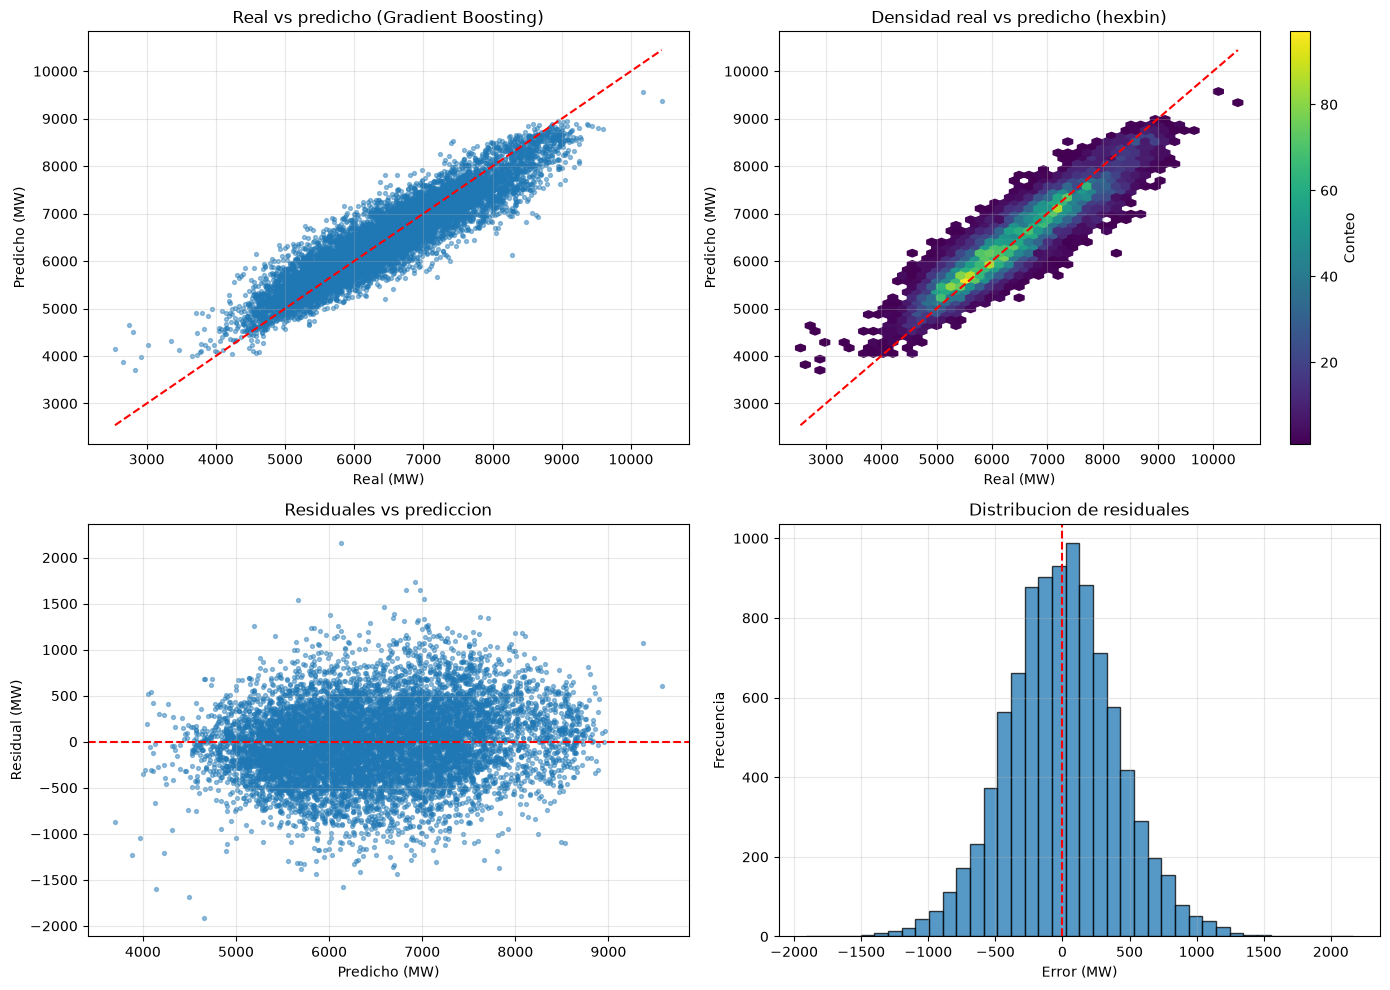

In [7]:
# Analisis de predicciones para split aleatorio (sin orden temporal)
pred_df = pd.DataFrame(index=y_test.index)
pred_df['Consumption'] = y_test
pred_df['pred_gbm'] = pred_gbm
pred_df['error_gbm'] = pred_df['Consumption'] - pred_df['pred_gbm']
pred_df['abs_error'] = pred_df['error_gbm'].abs()

print('Resumen de error en test:')
print(pred_df[['error_gbm', 'abs_error']].describe().round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Parity plot: real vs predicho
axes[0, 0].scatter(pred_df['Consumption'], pred_df['pred_gbm'], s=8, alpha=0.45)
min_v = min(pred_df['Consumption'].min(), pred_df['pred_gbm'].min())
max_v = max(pred_df['Consumption'].max(), pred_df['pred_gbm'].max())
axes[0, 0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 0].set_title('Real vs predicho (Gradient Boosting)')
axes[0, 0].set_xlabel('Real (MW)')
axes[0, 0].set_ylabel('Predicho (MW)')
axes[0, 0].grid(alpha=0.3)

# 2) Hexbin para densidad de puntos
hb = axes[0, 1].hexbin(
    pred_df['Consumption'],
    pred_df['pred_gbm'],
    gridsize=45,
    cmap='viridis',
    mincnt=1
)
axes[0, 1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 1].set_title('Densidad real vs predicho (hexbin)')
axes[0, 1].set_xlabel('Real (MW)')
axes[0, 1].set_ylabel('Predicho (MW)')
axes[0, 1].grid(alpha=0.3)
fig.colorbar(hb, ax=axes[0, 1], label='Conteo')

# 3) Residuales vs prediccion
axes[1, 0].scatter(pred_df['pred_gbm'], pred_df['error_gbm'], s=8, alpha=0.45)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Residuales vs prediccion')
axes[1, 0].set_xlabel('Predicho (MW)')
axes[1, 0].set_ylabel('Residual (MW)')
axes[1, 0].grid(alpha=0.3)

# 4) Histograma de residuales
axes[1, 1].hist(pred_df['error_gbm'], bins=40, edgecolor='black', alpha=0.75)
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].set_title('Distribucion de residuales')
axes[1, 1].set_xlabel('Error (MW)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Analisis de coeficientes de la regresion lineal

A partir de los coeficientes estimados (`coef_df`, mostrado en la celda 6), se observan los siguientes patrones:

1. **Predominio de la estacionalidad horaria**
- Las variables dummy de `hour` aparecen entre los coeficientes de mayor magnitud absoluta.
- Esto indica que, manteniendo constantes las demas variables, la hora del dia explica una parte importante del nivel de `Consumption`.
- En terminos practicos, el modelo esta capturando correctamente el ciclo intradiario de demanda.

2. **Interpretacion del signo en variables dummy**
- Un coeficiente positivo en una dummy (por ejemplo, `hour_13`) implica que esa categoria tiende a elevar el consumo respecto a la categoria base omitida por el encoder (`drop='first'`).
- Un coeficiente negativo implicaria lo contrario: menor consumo relativo a la categoria base.

3. **Aporte de variables energeticas de origen**
- Variables como `Production`, `Oil and Gas`, `Coal` o `Hydroelectric` tambien aportan explicacion del consumo.
- Su interpretacion debe hacerse con cuidado porque pueden estar fuertemente correlacionadas entre si y con la propia dinamica temporal.

4. **Cautela: magnitud no siempre equivale a causalidad directa**
- En presencia de multicolinealidad (comun cuando se usan muchas dummies y variables energeticas relacionadas), los coeficientes pueden volverse inestables.
- Por ello, el analisis de coeficientes debe complementarse con metricas de desempeno (MAE, RMSE, R2, MAPE), validacion temporal y, si se requiere inferencia mas robusta, regularizacion (Ridge/Lasso).

5. **Conclusion del modelo actual**
- La regresion lineal esta capturando razonablemente bien la estructura del problema gracias a:
  - dummies temporales (hora/dia/mes/trimestre/anio),
  - `day_of_year` como tendencia estacional,
  - variables energeticas operativas del sistema.
- El resultado es consistente con el salto de desempeno observado frente a la version con features temporales mas simples.

## Ajuste y analisis del arbol de regresion

En esta seccion se realizan tres tareas:
1. Seleccion de hiperparametros mediante validacion cruzada.
2. Analisis de importancia de features del arbol ajustado.
3. Visualizacion grafica de una version podada del arbol.

In [8]:
# Validacion cruzada para seleccionar hiperparametros del GBM
from sklearn.model_selection import GridSearchCV, KFold

cv_gbm = KFold(n_splits=3, shuffle=True, random_state=42)
param_grid_gbm = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'min_samples_leaf': [2, 5],
}

gbm_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_gbm,
    scoring='neg_root_mean_squared_error',
    cv=cv_gbm,
    n_jobs=-1,
    refit=True,
)
gbm_search.fit(X_train, y_train)

best_gbm_params = gbm_search.best_params_
best_gbm_model = gbm_search.best_estimator_

pred_val_gbm_cv = best_gbm_model.predict(X_val)
pred_test_gbm_cv = best_gbm_model.predict(X_test)

gbm_cv_results = pd.DataFrame([
    {
        'split': 'validation',
        'modelo': 'GradientBoostingRegressor (CV)',
        'MAE': mean_absolute_error(y_val, pred_val_gbm_cv),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val_gbm_cv)),
        'R2': r2_score(y_val, pred_val_gbm_cv),
        'MAPE_%': mape(y_val, pred_val_gbm_cv),
    },
    {
        'split': 'test',
        'modelo': 'GradientBoostingRegressor (CV)',
        'MAE': mean_absolute_error(y_test, pred_test_gbm_cv),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_test_gbm_cv)),
        'R2': r2_score(y_test, pred_test_gbm_cv),
        'MAPE_%': mape(y_test, pred_test_gbm_cv),
    },
]).set_index(['split', 'modelo'])

gbm_cv_results_df = pd.DataFrame(gbm_search.cv_results_).sort_values(
    'rank_test_score'
).head(10)

print('Mejores hiperparametros encontrados:')
print(best_gbm_params)
print('\nMetricas del GBM ajustado por validacion cruzada:')
display(gbm_cv_results.round(4))
print('\nTop 10 configuraciones por RMSE promedio en CV:')
display(
    gbm_cv_results_df[
        ['param_n_estimators', 'param_learning_rate', 'param_max_depth',
         'param_min_samples_leaf', 'mean_test_score', 'std_test_score', 'rank_test_score']
    ].assign(mean_RMSE=lambda df: -df['mean_test_score'])
    .drop(columns='mean_test_score')
    .round(4)
)

Mejores hiperparametros encontrados:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 200}

Metricas del GBM ajustado por validacion cruzada:


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,GradientBoostingRegressor (CV),272.0481,349.5129,0.8917,4.3001
test,GradientBoostingRegressor (CV),269.8559,348.4667,0.8934,4.2642



Top 10 configuraciones por RMSE promedio en CV:


,param_n_estimators,param_learning_rate,param_max_depth,param_min_samples_leaf,std_test_score,rank_test_score,mean_RMSE
15,200,0.10,3,5,0.6768,1,352.2638
13,200,0.10,3,2,0.0607,2,352.4545
12,100,0.10,3,2,0.8787,3,416.2440
14,100,0.10,3,5,0.5834,4,416.2490
9,200,0.10,2,2,0.6998,5,416.9996
11,200,0.10,2,5,1.8898,6,417.0003
5,200,0.05,3,2,1.6751,7,417.3943
7,200,0.05,3,5,1.3109,8,417.9105
1,200,0.05,2,2,0.8910,9,484.7935
8,100,0.10,2,2,1.3273,10,484.8912


### Importancia de features del arbol ajustado

La importancia de cada feature se calcula a partir de la reduccion total de impureza aportada por los nodos que utilizan esa variable. Valores mayores indican mayor contribucion al ajuste del arbol, pero no implican causalidad.

Features mas importantes del GBM ajustado:


,feature,importance
0,Production,0.454201
4,Oil and Gas,0.077778
6,Solar,0.063467
5,Coal,0.063427
2,Wind,0.041682
3,Hydroelectric,0.039436
37,day_of_week_6,0.038330
8,day_of_year,0.023757
55,year_2023,0.020388
7,Biomass,0.017853


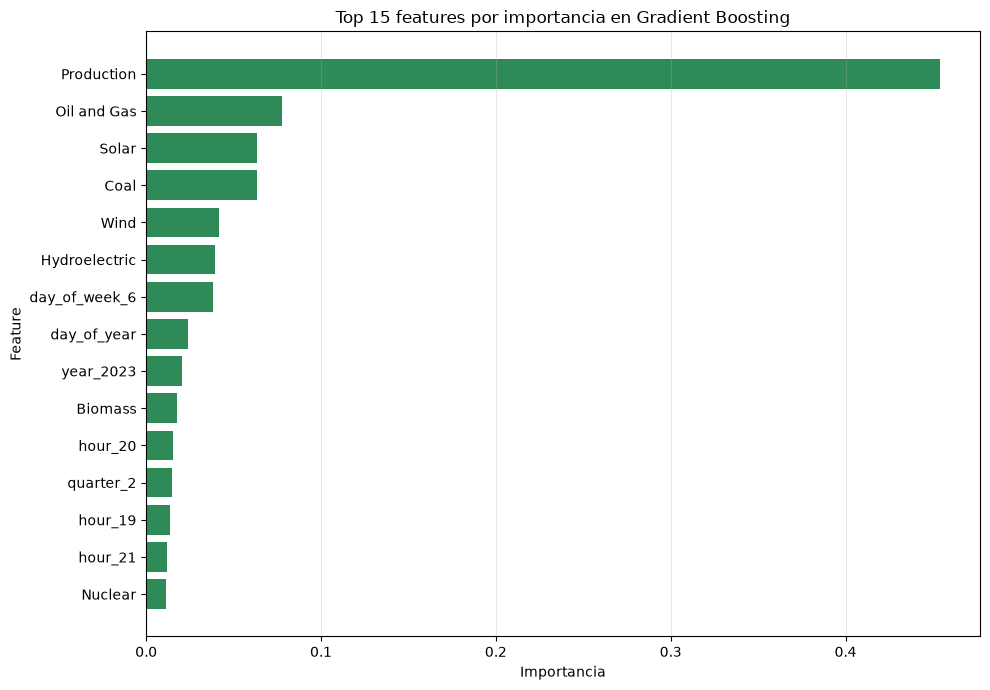

In [9]:
# Tabla y grafico de importancia de features del mejor GBM
feature_importance_cv_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': best_gbm_model.feature_importances_,
}).sort_values('importance', ascending=False)

print('Features mas importantes del GBM ajustado:')
display(feature_importance_cv_df.head(15).round(6))

importance_plot_df = feature_importance_cv_df.head(15).sort_values('importance')
plt.figure(figsize=(10, 7))
plt.barh(importance_plot_df['feature'], importance_plot_df['importance'], color='seagreen')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.title('Top 15 features por importancia en Gradient Boosting')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Grafico del arbol de regresion

Se visualiza una version limitada a los primeros niveles para conservar legibilidad. El modelo completo sigue siendo `best_tree_model`.

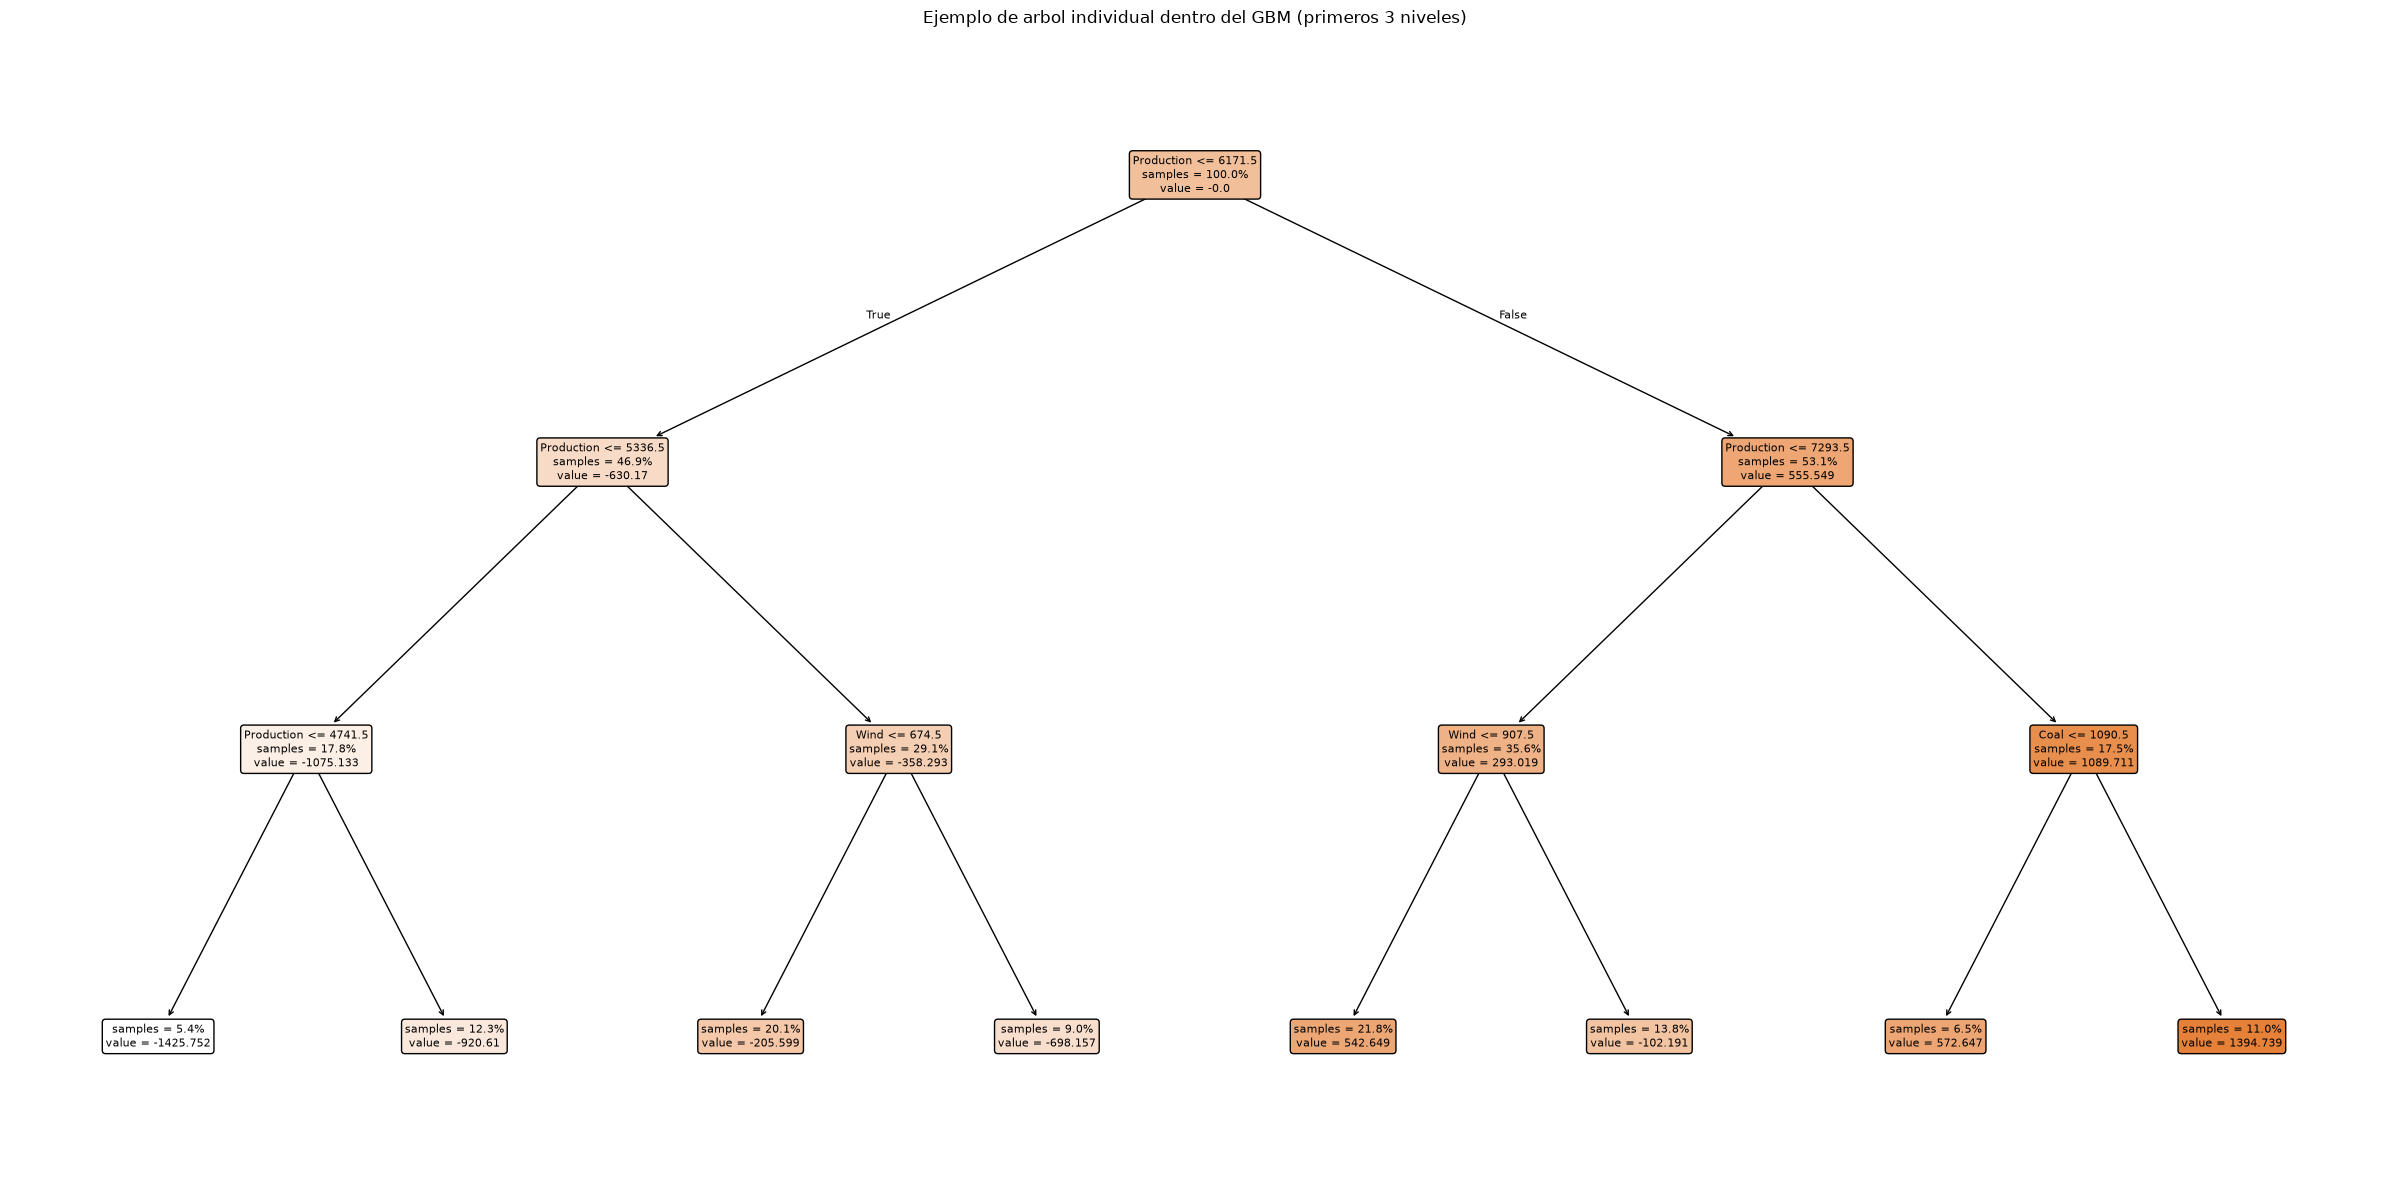

In [10]:
# Visualizacion de un arbol individual del mejor GBM
from sklearn.tree import plot_tree

example_tree = best_gbm_model.estimators_[0, 0]
plt.figure(figsize=(24, 12))
plot_tree(
    example_tree,
    feature_names=FEATURES,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    impurity=False,
    proportion=True,
)
plt.title('Ejemplo de arbol individual dentro del GBM (primeros 3 niveles)')
plt.tight_layout()
plt.show()

## Desempeno predictivo del mejor Gradient Boosting

El siguiente panel resume el comportamiento predictivo del modelo GBM seleccionado por validacion cruzada. Se utiliza el conjunto de test, que no participo en la busqueda de hiperparametros.

Hiperparametros del mejor GBM:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 200}

Metricas finales en test:


,metrica,valor
0,MAE,269.8559
1,RMSE,348.4667
2,R2,0.8934
3,MAPE_%,4.2642


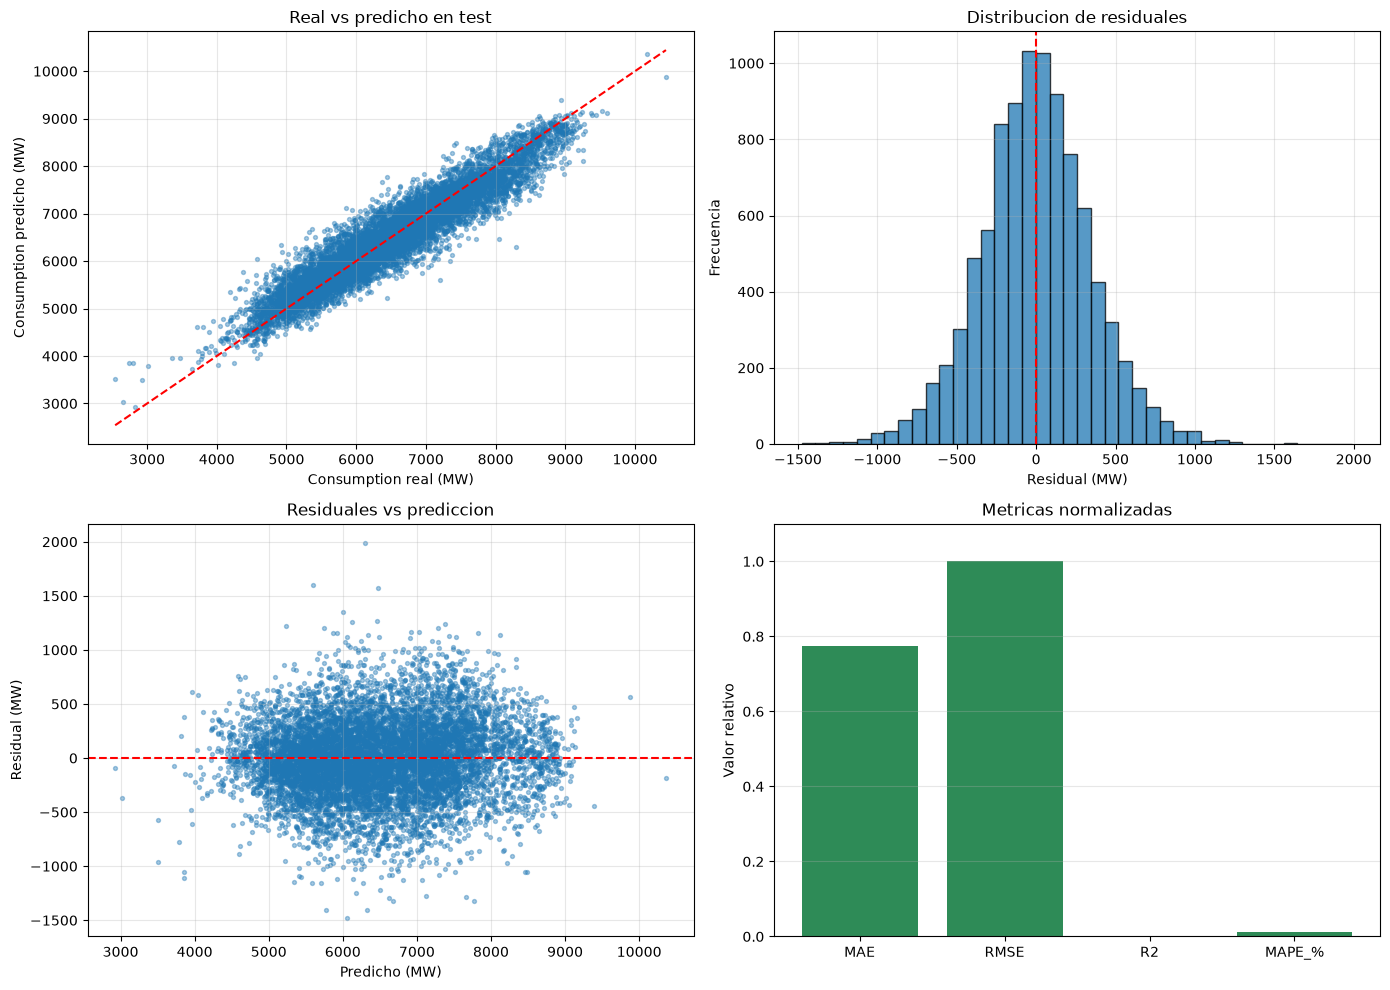

In [11]:
# Panel de desempeno predictivo del mejor GBM en test
if 'best_gbm_model' not in globals():
    raise NameError("Ejecuta primero la celda de validacion cruzada del GBM.")

best_pred_test = best_gbm_model.predict(X_test)
test_residuals = y_test.to_numpy() - best_pred_test

performance_metrics = pd.DataFrame({
    'metrica': ['MAE', 'RMSE', 'R2', 'MAPE_%'],
    'valor': [
        mean_absolute_error(y_test, best_pred_test),
        np.sqrt(mean_squared_error(y_test, best_pred_test)),
        r2_score(y_test, best_pred_test),
        mape(y_test, best_pred_test),
    ],
})

print('Hiperparametros del mejor GBM:')
print(best_gbm_params)
print('\nMetricas finales en test:')
display(performance_metrics.round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Real vs predicho
axes[0, 0].scatter(y_test, best_pred_test, s=8, alpha=0.4)
min_value = min(y_test.min(), best_pred_test.min())
max_value = max(y_test.max(), best_pred_test.max())
axes[0, 0].plot([min_value, max_value], [min_value, max_value], 'r--', linewidth=1.5)
axes[0, 0].set_title('Real vs predicho en test')
axes[0, 0].set_xlabel('Consumption real (MW)')
axes[0, 0].set_ylabel('Consumption predicho (MW)')
axes[0, 0].grid(alpha=0.3)

# 2) Distribucion de residuales
axes[0, 1].hist(test_residuals, bins=40, edgecolor='black', alpha=0.75)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('Distribucion de residuales')
axes[0, 1].set_xlabel('Residual (MW)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(alpha=0.3)

# 3) Residuales frente a la prediccion
axes[1, 0].scatter(best_pred_test, test_residuals, s=8, alpha=0.4)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Residuales vs prediccion')
axes[1, 0].set_xlabel('Predicho (MW)')
axes[1, 0].set_ylabel('Residual (MW)')
axes[1, 0].grid(alpha=0.3)

# 4) Barras de metricas normalizadas para comparar escalas
metric_values = performance_metrics.set_index('metrica')['valor']
normalized_values = metric_values / metric_values.max()
axes[1, 1].bar(normalized_values.index, normalized_values.values, color='seagreen')
axes[1, 1].set_title('Metricas normalizadas')
axes[1, 1].set_ylabel('Valor relativo')
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()